# Material properties from the input files

Read the current defaults directly from `inputs/materials/<Material>/<property>.txt`.
No constitutive formulas or legacy conversion factors are reproduced here.
**Run All** after editing a data file to refresh every plot.

- A single number is a constant; two columns are concentration and property value.
- Only files directly inside each material folder are loaded; `legacy/` is excluded.
- These plots show the default library, **not run-config overrides**.
- Electrodes use stoichiometry; electrolyte uses concentration in mol/cm³.

See [the material data guide](../inputs/materials/README.md) for units and conventions.

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Set this to a specific materials directory, or leave None to find the repo data.
MATERIAL_DIR = None
SHOW_TABLE_POINTS = False
SILICON_WINDOW = (0.01, 0.99)
SAVE_FIGURES = False

if MATERIAL_DIR is None:
    candidates = [parent / "inputs" / "materials"
                  for parent in (Path.cwd(), *Path.cwd().parents)]
    MATERIAL_DIR = next((p for p in candidates if p.is_dir()), None)
    if MATERIAL_DIR is None:
        raise FileNotFoundError("Set MATERIAL_DIR to BESFEM/inputs/materials.")
MATERIAL_DIR = Path(MATERIAL_DIR).expanduser().resolve()
EXPORT_DIR = MATERIAL_DIR.parent.parent / "plotting" / "material_property_figures"

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 10})
print(f"Reading material data from: {MATERIAL_DIR}")

Reading material data from: /mnt/ffs24/home/brandlan/BESFEM/inputs/materials


## Read and validate the library

The inventory reports the actual table ranges and scalar values. No missing
property is filled with zero, and no extra unit conversions are applied.
The loader rejects malformed rows, nonfinite values, invalid concentrations,
and invalid signs for transport properties.

In [8]:
NONNEGATIVE = {"diffusivity", "mobility", "conductivity", "exchange_current_density"}
LABELS = {
    "ocv": "OCV [V]",
    "chemical_potential": "Chemical potential [stored model units]",
    "exchange_current_density": "Exchange current density [A/cm²]",
    "diffusivity": "Diffusivity [cm²/s]",
    "mobility": "Mobility [stored model units]",
    "conductivity": "Conductivity [S/cm]",
    "site_density": "Site density [mol/cm³]",
}

def read_property(path, material):
    rows = []
    for line_number, line in enumerate(path.read_text().splitlines(), 1):
        line = line.split("#", 1)[0].strip()
        if not line:
            continue
        try:
            values = [float(token) for token in line.split()]
        except ValueError as error:
            raise ValueError(f"{path}:{line_number}: expected numeric data") from error
        if len(values) not in (1, 2) or not np.all(np.isfinite(values)):
            raise ValueError(f"{path}:{line_number}: expected one or two finite numbers")
        rows.append(values)
    scalar = len(rows) == 1 and len(rows[0]) == 1
    if scalar:
        x, y = None, np.array([rows[0][0]])
    else:
        if len(rows) < 2 or any(len(row) != 2 for row in rows):
            raise ValueError(f"{path}: expected one scalar or at least two x/y rows")
        x, y = np.asarray(rows).T
        if np.any(np.diff(x) <= 0):
            raise ValueError(f"{path}: concentrations must strictly increase")
        if np.any(x < 0) or (material != "Electrolyte" and np.any(x > 1)):
            raise ValueError(f"{path}: concentration outside the physical domain")
    if path.stem == "site_density" and (not scalar or y[0] <= 0):
        raise ValueError(f"{path}: site density must be a positive scalar")
    if path.stem in NONNEGATIVE and np.any(y < 0):
        raise ValueError(f"{path}: property must be nonnegative")
    return {"path": path, "x": x, "y": y, "scalar": scalar}

library = {}
records = []
for folder in sorted(MATERIAL_DIR.iterdir()):
    if not folder.is_dir():
        continue
    properties = {p.stem: read_property(p, folder.name)
                  for p in sorted(folder.glob("*.txt"))}
    if not properties:
        continue
    library[folder.name] = properties
    for name, data in properties.items():
        records.append({
            "material": folder.name, "property": name,
            "kind": "constant" if data["scalar"] else "table",
            "rows": len(data["y"]),
            "concentration min": np.nan if data["scalar"] else data["x"][0],
            "concentration max": np.nan if data["scalar"] else data["x"][-1],
            "value min": data["y"].min(), "value max": data["y"].max(),
            "file": str(data["path"].relative_to(MATERIAL_DIR)),
        })
if not library:
    raise ValueError(f"No material property files found in {MATERIAL_DIR}")
inventory = pd.DataFrame(records)
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(inventory)
print(f"Loaded {len(inventory)} properties across {len(library)} materials.")

,material,property,kind,rows,concentration min,concentration max,value min,value max,file
0,Carbon,chemical_potential,table,2231,0.0,1.00,-1.121652e+00,-0.000000e+00,Carbon/chemical_potential.txt
1,Carbon,conductivity,constant,1,NaN,NaN,1.000000e+00,1.000000e+00,Carbon/conductivity.txt
2,Carbon,diffusivity,constant,1,NaN,NaN,1.000000e-10,1.000000e-10,Carbon/diffusivity.txt
3,Carbon,exchange_current_density,table,101,-0.0,1.00,4.100000e-04,2.681749e-03,Carbon/exchange_current_density.txt
4,Carbon,ocv,table,2231,0.0,1.00,0.000000e+00,1.121652e+00,Carbon/ocv.txt
5,Carbon,site_density,constant,1,NaN,NaN,2.270000e-02,2.270000e-02,Carbon/site_density.txt
6,Electrolyte,diffusivity,table,2273,0.0,0.01,1.395193e-07,4.370807e-06,Electrolyte/diffusivity.txt
7,Graphite,chemical_potential,table,101,-0.0,1.00,-5.565340e-01,1.675000e-01,Graphite/chemical_potential.txt
8,Graphite,conductivity,constant,1,NaN,NaN,3.300000e+00,3.300000e+00,Graphite/conductivity.txt
9,Graphite,exchange_current_density,table,101,-0.0,1.00,4.100000e-04,2.681749e-03,Graphite/exchange_current_density.txt


Loaded 32 properties across 6 materials.


## Plot each material

<!-- Lines connect the original table knots, matching linear interpolation without
resampling away narrow features. Constants appear as horizontal lines (their
concentration span is only for display). Each panel labels its own range and units.
Silicon uses the same property grid as the other materials, with OCV and chemical
potential shown only over `SILICON_WINDOW` (default 0.01–0.99) to reveal their
interior curves. This changes the plotted interval, not the stored data. -->

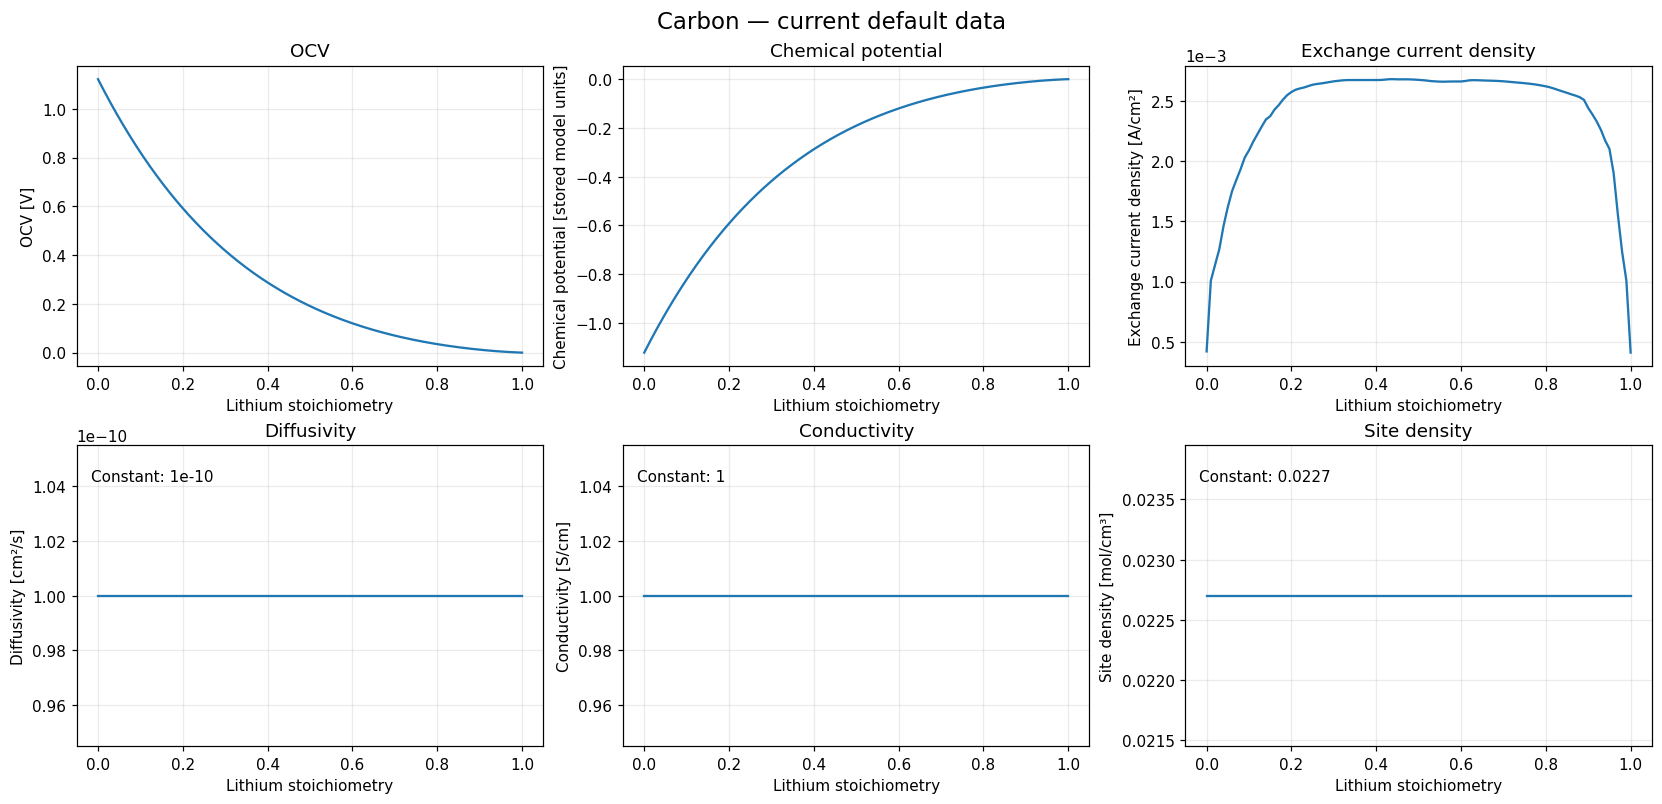

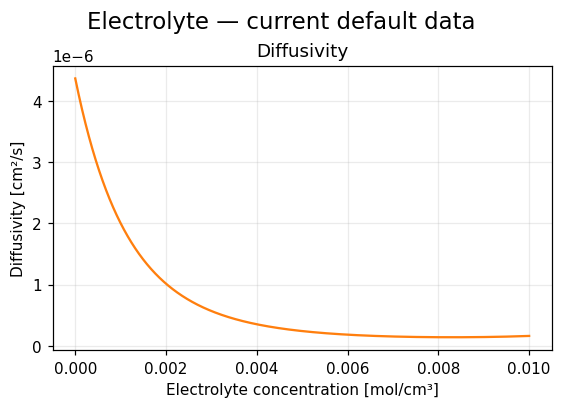

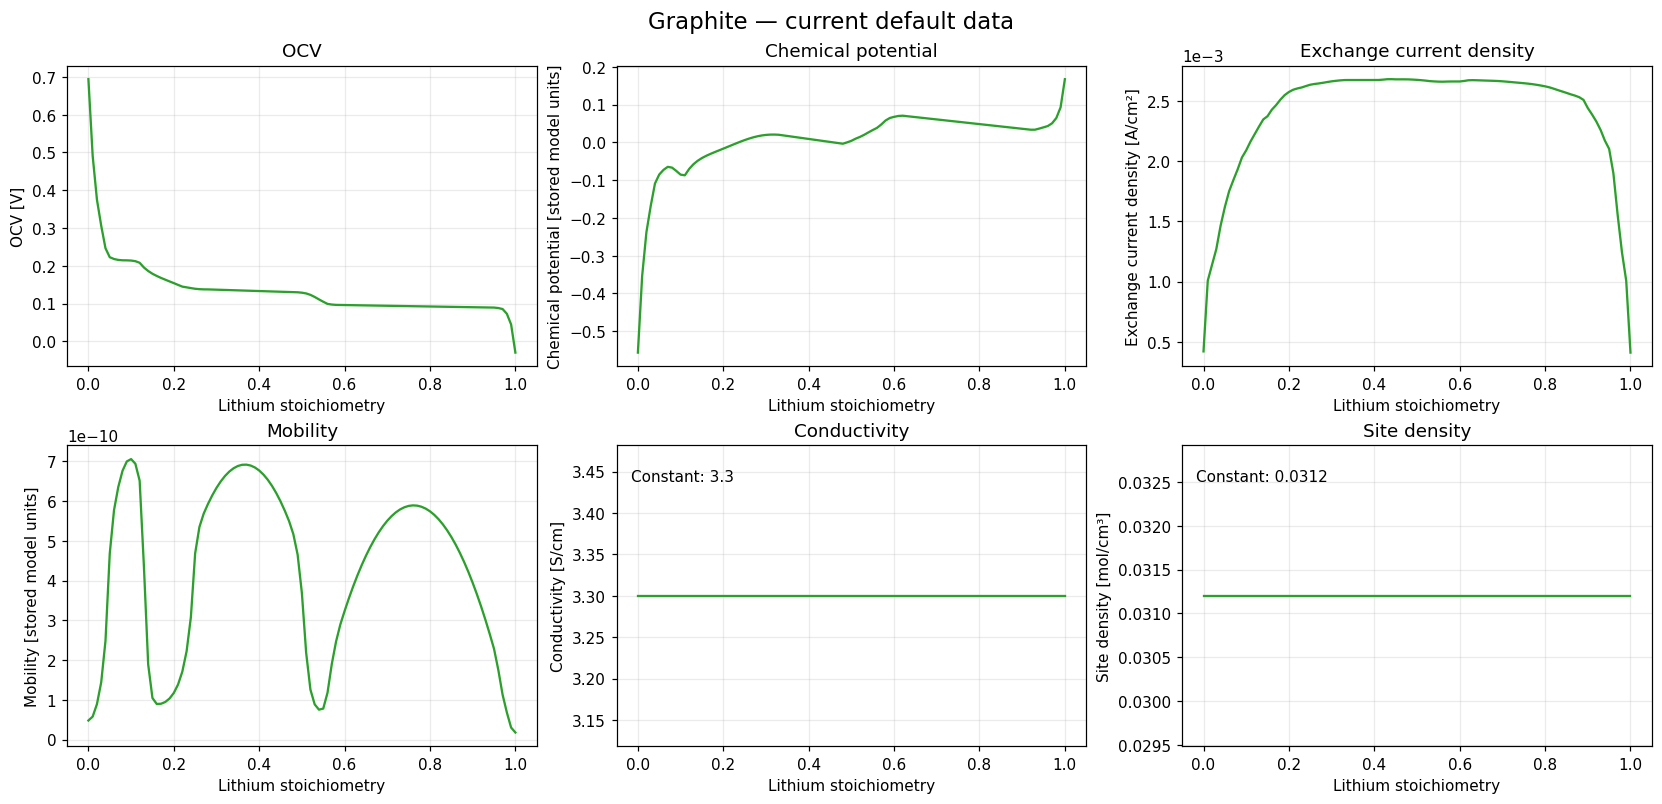

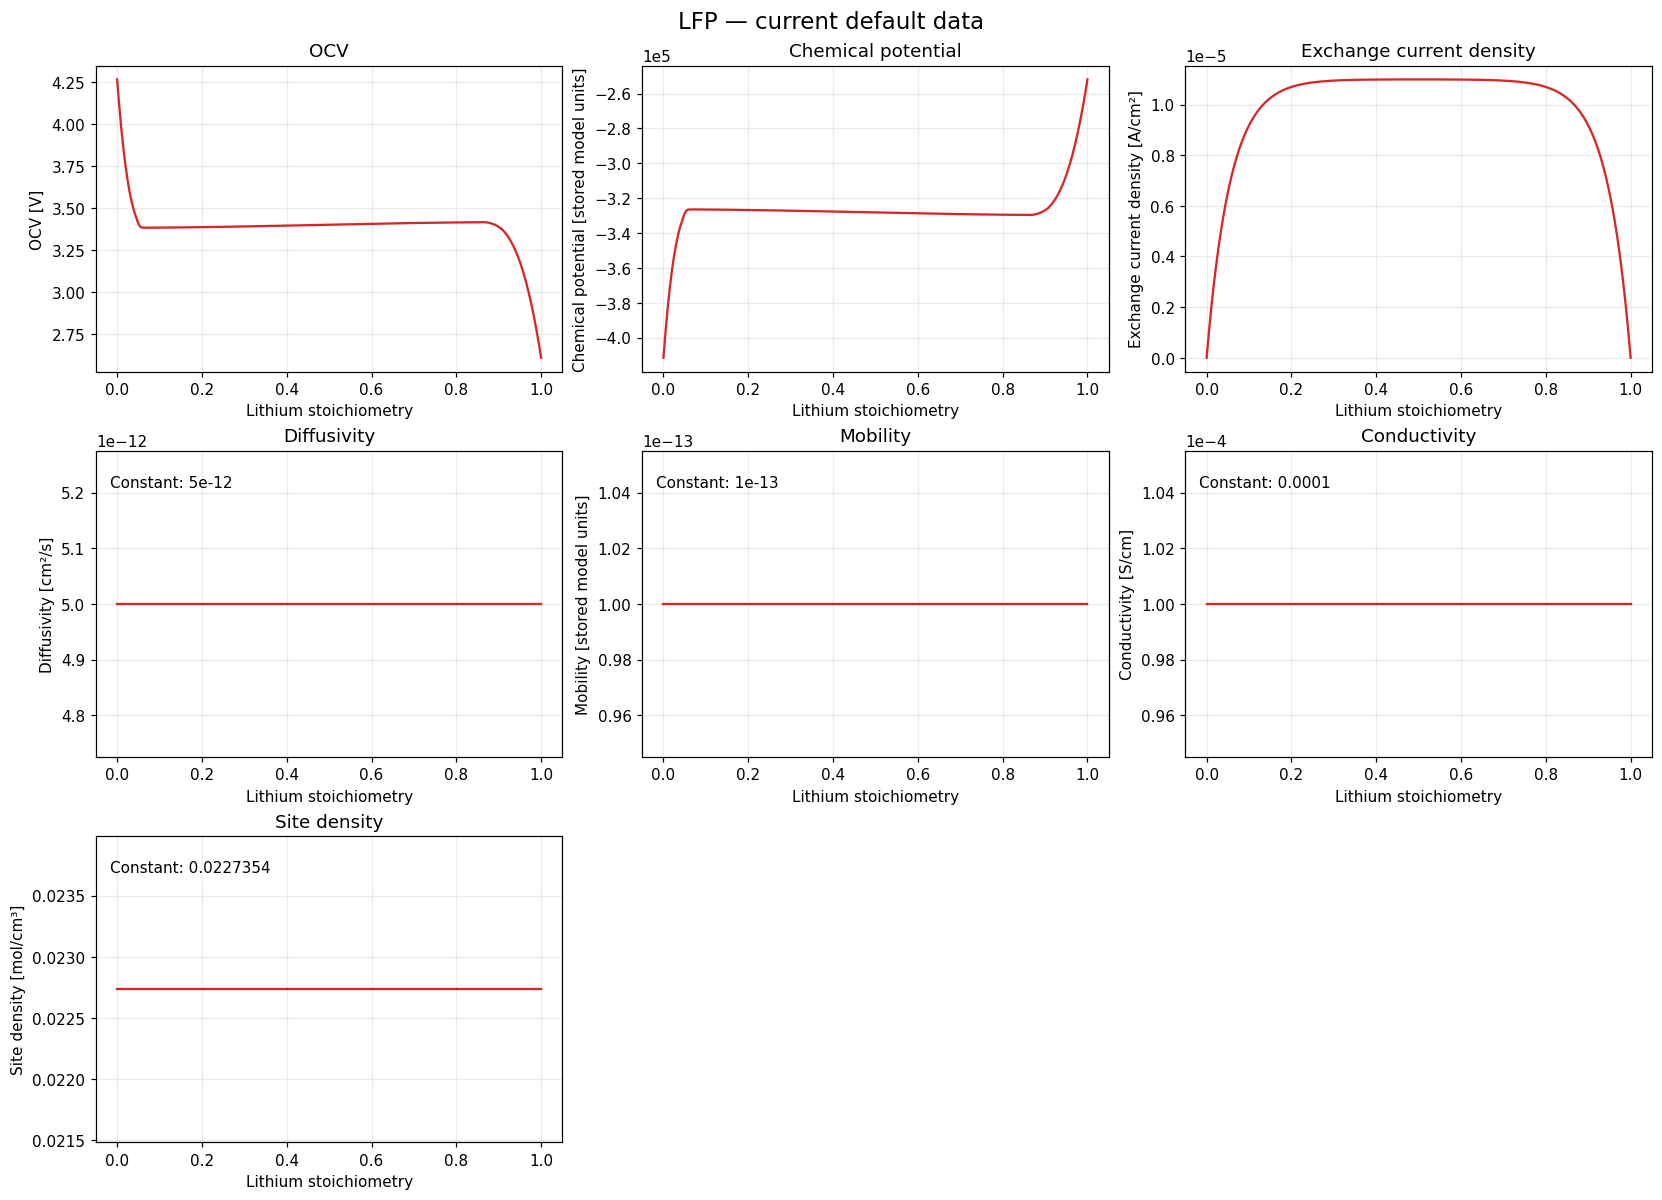

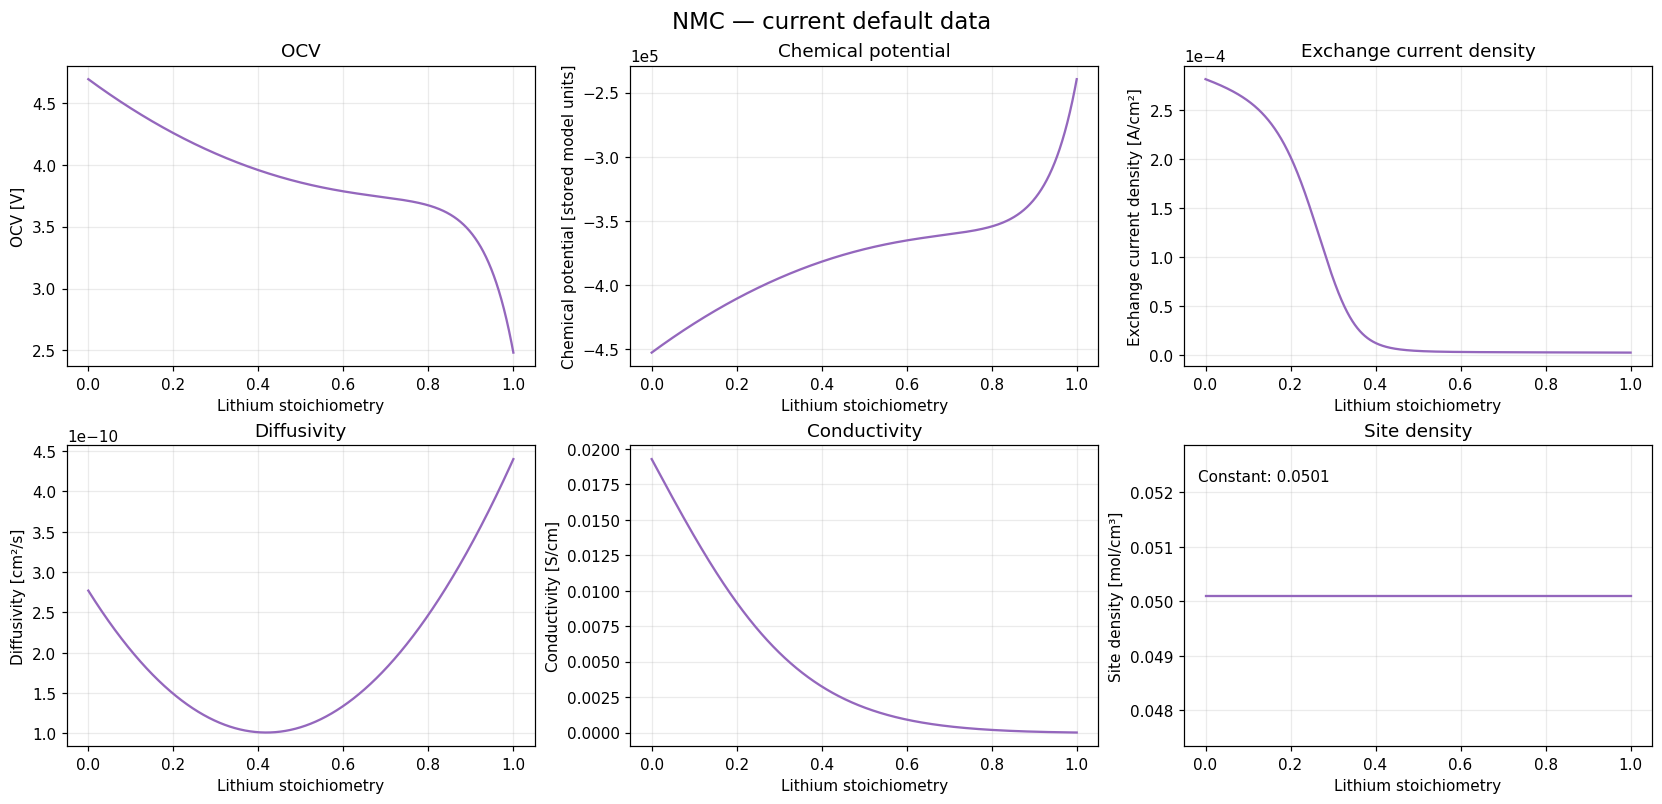

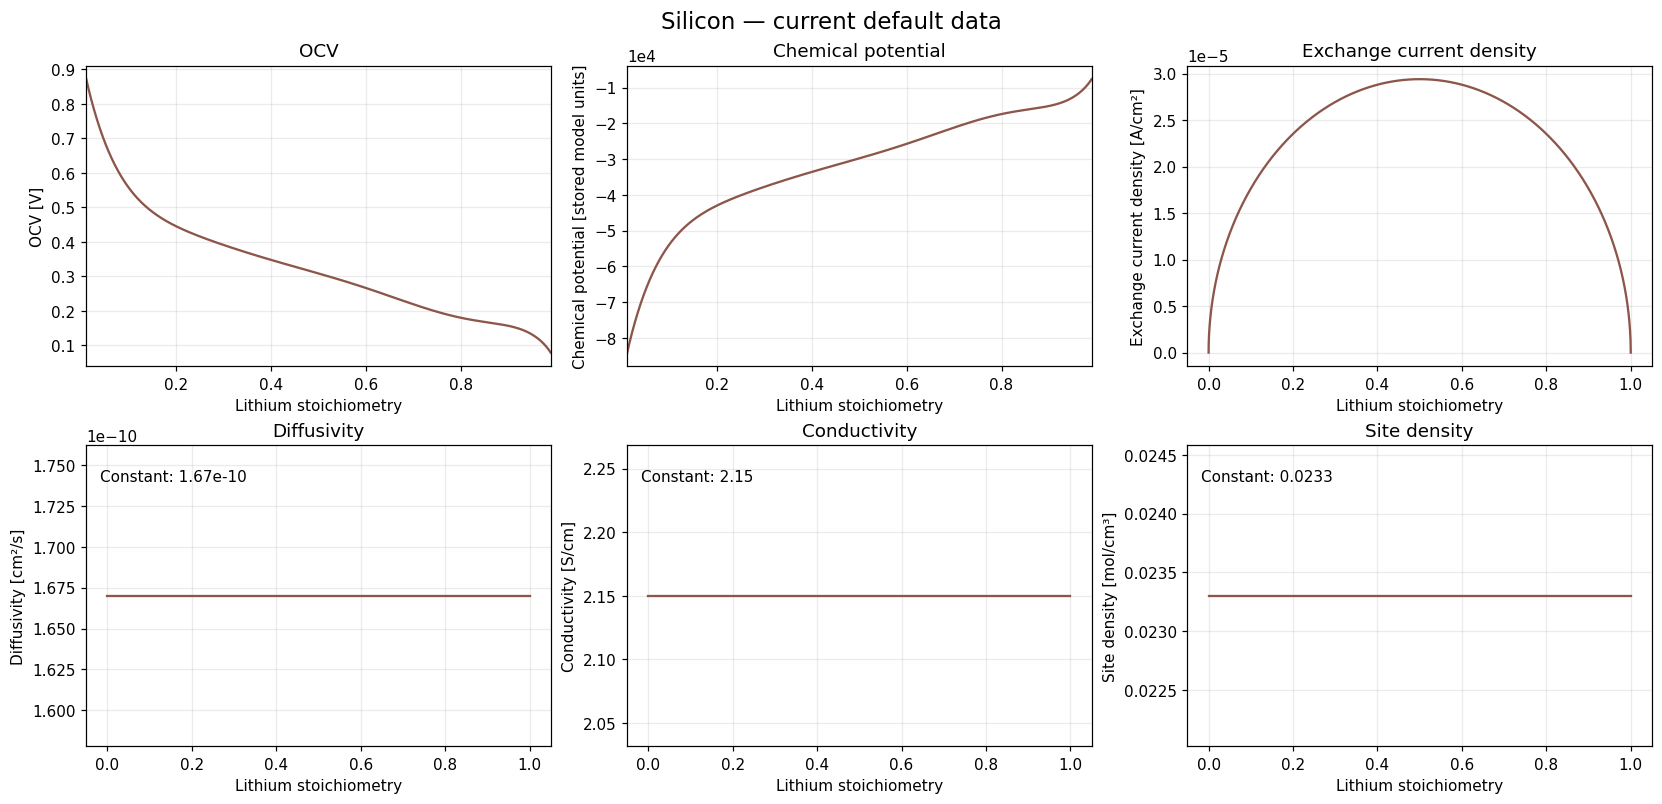

In [9]:
COLORS = {material: plt.get_cmap("tab10")(i % 10)
          for i, material in enumerate(library)}

def evaluate(data, concentration):
    """Match scalar evaluation and linear interpolation with endpoint clamping."""
    concentration = np.asarray(concentration, dtype=float)
    if not np.all(np.isfinite(concentration)):
        raise ValueError("Concentration must be finite")
    if data["scalar"]:
        return np.full_like(concentration, data["y"][0])
    return np.interp(concentration, data["x"], data["y"])


def plot_data(ax, material, name, data, window=None, label=None):
    if data["scalar"]:
        domain = window if window is not None else (0.0, 1.0)
        ax.plot(domain, [data["y"][0]] * 2, label=label, color=COLORS[material])
        if label is None:
            ax.text(0.03, 0.92, f"Constant: {data['y'][0]:.6g}",
                    transform=ax.transAxes, va="top")
    else:
        x, y = data["x"], data["y"]
        if window is not None:
            lo, hi = max(window[0], x[0]), min(window[1], x[-1])
            if lo >= hi:
                raise ValueError(f"{material}.{name}: no overlap with plot window")
            x = np.r_[lo, x[(x > lo) & (x < hi)], hi]
            y = evaluate(data, x)
        ax.plot(x, y, label=label, color=COLORS[material])
        if SHOW_TABLE_POINTS:
            mask = np.ones(len(data["x"]), dtype=bool) if window is None else (
                (data["x"] >= window[0]) & (data["x"] <= window[1]))
            ax.plot(data["x"][mask], data["y"][mask], ".", ms=2, alpha=0.5, color=COLORS[material])
    ax.set_xlabel("Electrolyte concentration [mol/cm³]" if material == "Electrolyte"
                  else "Lithium stoichiometry")
    ax.set_ylabel(LABELS.get(name, ("OCV" if name == "ocv" else name.replace("_", " ").capitalize()) + " [stored units]"))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 4), useOffset=False)
    if window is not None:
        ax.set_xlim(window)


def finish(fig, filename):
    if SAVE_FIGURES:
        EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(EXPORT_DIR / f"{filename}.png", dpi=200, bbox_inches="tight")
        fig.savefig(EXPORT_DIR / f"{filename}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

for material, properties in library.items():
    names = [name for name in LABELS if name in properties]
    names += sorted(set(properties) - set(names))
    ncols = min(3, len(names))
    nrows = (len(names) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows),
                             squeeze=False, constrained_layout=True)
    for ax, name in zip(axes.flat, names):
        window = SILICON_WINDOW if material == "Silicon" and name in ("ocv", "chemical_potential") else None
        plot_data(ax, material, name, properties[name], window=window)
        title = "OCV" if name == "ocv" else name.replace("_", " ").capitalize()
        # if window is not None:
            # title += f" — interior {window[0]:g}–{window[1]:g}"
        ax.set_title(title)
    for ax in list(axes.flat)[len(names):]:
        ax.set_visible(False)
    fig.suptitle(f"{material} — current default data", fontsize=15)
    finish(fig, f"{material.lower()}_properties")

## Query a property

Change the material, property, and concentrations below. `evaluate` uses the
same linear interpolation and endpoint clamping as default table evaluation in
BESFEM. Constants do not depend on concentration. This does not read config
`error` policies or overrides.

In [10]:
QUERY_MATERIAL = "Graphite"
QUERY_PROPERTY = "ocv"
QUERY_CONCENTRATIONS = np.array([0.03, 0.25, 0.5, 0.95])
data = library[QUERY_MATERIAL][QUERY_PROPERTY]
display(pd.DataFrame({
    "material": QUERY_MATERIAL,
    "property": QUERY_PROPERTY,
    "concentration": QUERY_CONCENTRATIONS,
    "value (stored units)": evaluate(data, QUERY_CONCENTRATIONS),
}))
print(f"Source: {data['path']}")

,material,property,concentration,value (stored units)
0,Graphite,ocv,0.03,0.305943
1,Graphite,ocv,0.25,0.139040
2,Graphite,ocv,0.50,0.128629
3,Graphite,ocv,0.95,0.089219


Source: /mnt/ffs24/home/brandlan/BESFEM/inputs/materials/Graphite/ocv.txt
